## 1. Configuração do Ambiente e Importação de Bibliotecas

Nesta etapa, foi realizado os imports necessarios para realizar a atividade


In [42]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


## 2. Carregamento dos Dados

Obtemos os conjuntos de dados disponibilizados para o projeto:
* **`beans_train.csv`**: Conjunto rotulado com as amostras de feijões contendo 16 tipos de feijõesa na feature `Class`.
* **`beans_test.csv`**: Conjunto cego de teste que sera apenas usado na competição com 2.723 instâncias (sem a coluna `Class`)

In [ ]:
!git clone https://github.com/silvaan/deep-learning.git # substitua isso para o caminho onde está os datasetes
caminho_treino = "deep-learning/atividades/01-beans/data/beans_train.csv"
caminho_teste  = "deep-learning/atividades/01-beans/data/beans_test.csv"

fatal: destination path 'deep-learning' already exists and is not an empty directory.


In [ ]:
# dataset que será usado ja passam pelo dataframe 
df_train = pd.read_csv(caminho_treino)
df_test = pd.read_csv(caminho_teste)

### 2.1 Inspeção Inicial das Amostras

Visualizamos os primeiros registros de `df_train` e `df_test` para analisar a estrutura das variáveis:
* **Grandezas geométricas lineares e superficiais**: Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, EquivDiameter.
* **Razões de aspecto e excentricidade**: AspectRation, Eccentricity, Extent, Solidity, roundness, Compactness.


In [45]:
df_train.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,38465.705594,737.090445,273.111968,179.201525,1.523333,0.753998,38999.014066,220.991553,0.813252,0.988670,0.888416,0.809359,0.007117,0.001879,0.655710,0.996874,SIRA
1,70247.179155,1019.740591,376.308440,238.192942,1.582115,0.773556,71562.831696,299.139162,0.707757,0.985750,0.850248,0.794947,0.005351,0.001324,0.632118,0.998320,BARBUNYA
2,74212.949558,1049.756998,414.858346,229.655950,1.810139,0.834413,75004.806409,306.719019,0.776048,0.987679,0.844313,0.739884,0.005597,0.001039,0.548725,0.991096,CALI
3,31233.029736,671.584675,257.751304,154.448259,1.670969,0.800540,31682.423625,198.813755,0.718182,0.988299,0.870828,0.773574,0.008257,0.001822,0.598230,0.996528,DERMASON
4,48189.750788,826.752018,313.328739,196.497443,1.604009,0.781591,48840.530648,247.963648,0.796755,0.988498,0.887039,0.788613,0.006525,0.001556,0.622442,0.995508,SIRA


In [46]:
df_test.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,47797.967433,905.804704,282.048511,217.587896,1.298150,0.636983,48743.247518,246.694040,0.741867,0.981380,0.735352,0.877072,0.005876,0.002140,0.768456,0.996852
1,37159.253747,708.106996,242.384135,194.502880,1.243588,0.594251,37296.563833,216.792582,0.774812,0.987832,0.924631,0.896071,0.006546,0.002608,0.803774,0.999165
2,51120.875108,895.584991,369.719482,177.554072,2.078186,0.875921,51602.320406,254.589849,0.602230,0.987474,0.799881,0.689471,0.007246,0.001011,0.475230,0.988491
3,72397.987727,1057.182263,394.900163,234.808004,1.678587,0.803881,73694.794287,304.902419,0.738333,0.984816,0.814761,0.770147,0.005428,0.001185,0.594574,0.998265
4,80512.447342,1113.930836,446.902900,233.131046,1.914719,0.853757,82128.189223,320.617158,0.711118,0.980865,0.815330,0.716261,0.005543,0.000905,0.513236,0.985316


### 2.2 Verificação de Integridade e Tipagem dos Dados

Notei q n existe a presença de valores ausentes (null / NaN) e a consistência dos tipos de dados. Os atributos de entrada são todos do tipo numérico contínuo (float64), não requerendo imputação prévia de valores ausentes.

In [47]:
print("\nValores nulos por coluna:\n", df_train.isnull().sum())
print(df_train.info())



Valores nulos por coluna:
 Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10888 entries, 0 to 10887
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             10888 non-null  float64
 1   Perimeter        10888 non-null  float64
 2   MajorAxisLength  10888 non-null  float64
 3   MinorAxisLength  10888 non-null  float64
 4   AspectRation     10888 non-null  float64
 5   Eccentricity     10888 non-null  float64
 6   ConvexArea       10888 non-null  float64
 7   EquivDiameter    10888 non-null  float64
 8   Extent           10888 non-n

### 2.3 Análise do Desbalanceamento de Classes

Examinamos a contagem e a proporção de cada uma das 7 espécies de grãos no conjunto de treinamento.

Como visto na contagem, o conjunto apresenta desbalanceamento considerável: a classe majoritária possui quase 7 vezes mais instâncias do que a classe minoritária.

> Para impedir que as divisões de validação ou teste recebam proporções distorcidas de classes raras, é imprescindível utilizar **amostragem estratificada (`stratify=y`)** em todos os particionamentos.


In [48]:
print("\nDistribuição das classes:\n", df_train['Class'].value_counts())



Distribuição das classes:
 Class
DERMASON    2849
SIRA        2119
SEKER       1613
HOROZ       1522
CALI        1306
BARBUNYA    1063
BOMBAY       416
Name: count, dtype: int64


## 3. Pré-processamento e Particionamento dos Dados

Para garantir um passo a passo na construção do modelo e o fluxo de dados segue os seguintes passos:

1. **Separação de Variáveis**: Isolamento das 16 características preditoras ($X$) da variável dependente categórica ($y$).
2. **Codificação dos Rótulos (*LabelEncoder*)**: Mapeamento das 7 classes em texto para identificadores numéricos no intervalo $[0, 6]$, formato obrigatório para o cômputo da perda via nn.CrossEntropyLoss.
3. **Divisão Estratificada em Três Partições (70% Treino / 15% Validação / 15% Teste Interno)**:
   * **Treino (70%)**: Utilizado exclusivamente para guiar a atualização dos parâmetros do modelo via backpropagation.
   * **Validação (15%)**: Empregado para monitorar o risco de sobreajuste (*overfitting*), acionar o agendador de taxa de aprendizado e salvar o melhor ponto de convergência (*checkpointing*).
   * **Teste Interno (15%)**: Mantido estritamente isolado de toda a tomada de decisão e calibragem de hiperparâmetros, simulando a generalização cega em dados não observados.
   * A estratificação (stratify=y) garante idêntica proporção de todas as 7 classes nas três partições.
4. **Padronização das Features (StandardScaler) e por fim o treinamento**


In [49]:
X = df_train.drop(columns=["Class"])
y_raw = df_train["Class"]

encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_val,
    y_val,
    test_size=0.5,
    random_state=42,
    stratify=y_val
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


## 4. Configuração do Hardware e Pipeline de Dados PyTorch


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")


Dispositivo em uso: cuda


### 4.1 Criação dos Tensores e DataLoaders

* **Conversão em Tensores**: As matrizes de entrada são convertidas para torch.float32 e os vetores de rótulos para torch.long.
* **Organização em Minibatches (DataLoader)**:
  * Utilizei BATCH_SIZE = 64. O tamanho de lote de 64 instâncias equilibra a estabilidade estatística das estimativas de Batch Normalization com o ruído de regularização intrínseco do gradiente estocástico.
  * O conjunto de treino é configurado com shuffle=True para quebrar correlações de ordem entre amostras a cada época.
  * Os conjuntos de validação e teste utilizam shuffle=False para avaliações determinísticas e reproduzíveis.


In [51]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches de treino: {len(train_loader)} (batch_size={BATCH_SIZE})")
print(f"Batches de validação: {len(val_loader)}")
print(f"Batches de teste: {len(test_loader)}")


Batches de treino: 120 (batch_size=64)
Batches de validação: 26
Batches de teste: 26


## 5. Modelagem: Arquitetura da Rede Neural (`BeansClassifier`)

Projetei uma rede neural organizada em 3 camadas ocultas sequenciais:

1. **Topologia e Projeção Dimensional ($16 \to 128 \to 64 \to 32 \to 7$)**:
   * A expansão inicial projeta os 16 atributos morfológicos em um espaço latente de maior dimensionalidade (128 neurônios), viabilizando a linearização de fronteiras de decisão complexas.
   * As camadas subsequentes (64 e 32) realizam uma redução dimensional progressiva, destilando representações abstratas robustas antes dos 7 logits de saída.
2. **Estabilidade via Batch Normalization (nn.BatchNorm1d)**:
   * Normaliza a média e a variância das ativações em cada minibatch, reescalando com parâmetros aprendíveis ($\gamma$ e $\beta$).
   * Reduz o deslocamento de covariável interno (*internal covariate shift*), suaviza a superfície de perda e permite um treinamento acelerado e estável.
3. **Função de Ativação ReLU (nn.ReLU)**:
   * Introduz não-linearidade eficiente assim eliminando a saturação de gradientes e n quebrando a lienalidade.
4. **Regularização com Dropout (nn.Dropout(p=0.2))**:
   * Zera aleatoriamente 20% das ativações dos neuronios durante o treinamento para evitar q o modelo decore os dados, forçando a rede a aprender representações não-redundantes e impedindo a co-adaptação excessiva aos dados de treino.
5. **Saída em Logits Lineares**:
   * A rede emite valores lineares não normalizados. A função nn.CrossEntropyLoss realiza internamente a operação Softmax, garantindo máxima estabilidade numérica contra underflow/overflow.


In [52]:
class BeansClassifier(nn.Module):
    def __init__(self, input_dim=16, num_classes=7, dropout_rate=0.2):
        super(BeansClassifier, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, num_classes)
        )
        
    def forward(self, x):
        return self.network(x)

model = BeansClassifier(input_dim=16, num_classes=7, dropout_rate=0.2).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


## 6. Otimização, Função de Custo e Estratégia de Treinamento

O protocolo de aprendizado baseado nas melhores práticas de regularização e controle de convergência:

* **Função de Custo Multiclasse (nn.CrossEntropyLoss)**:
  Calcula a perda da entropia cruzada categórica sobre a distribuição dos logits preditos em relação à classe real.
* **Agendador Dinâmico `ReduceLROnPlateau`**:
  * Monitora a perda de validação (`val_loss`). Ao detectar estagnação por 5 épocas consecutivas, reduz a taxa de aprendizado em 50%, permitindo passos mais sutis na bacia de convergência.
* **Mecanismo de Checkpointing do Melhor Modelo**:
  * Registra continuamente o melhor desempenho em validação (`best_val_acc`) e salva os pesos correspondentes (`best_model_weights`).
  * Ao término das 100 épocas, restaura o melhor estado da rede, garantindo que o modelo final corresponda ao ponto ótimo (`best_epoch`).


In [53]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

EPOCHS = 100
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_model_weights = None
best_epoch = 1

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    
    scheduler.step(epoch_val_loss)
    
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_weights = model.state_dict().copy()
        best_epoch = epoch
        
    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Época [{epoch:02d}/{EPOCHS}] | "
              f"Treino Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc*100:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc*100:.2f}%")

print(f"\nMelhor Acurácia de Validação: {best_val_acc*100:.2f}% na época {best_epoch}")
model.load_state_dict(best_model_weights)


Época [01/100] | Treino Loss: 0.9399, Acc: 78.87% | Val Loss: 0.4412, Acc: 91.00%
Época [10/100] | Treino Loss: 0.2832, Acc: 90.66% | Val Loss: 0.2321, Acc: 91.79%
Época [20/100] | Treino Loss: 0.2632, Acc: 91.16% | Val Loss: 0.2264, Acc: 92.35%
Época [30/100] | Treino Loss: 0.2537, Acc: 91.50% | Val Loss: 0.2209, Acc: 92.59%
Época [40/100] | Treino Loss: 0.2387, Acc: 91.88% | Val Loss: 0.2180, Acc: 91.98%
Época [50/100] | Treino Loss: 0.2300, Acc: 92.14% | Val Loss: 0.2181, Acc: 92.22%
Época [60/100] | Treino Loss: 0.2370, Acc: 91.96% | Val Loss: 0.2207, Acc: 92.28%
Época [70/100] | Treino Loss: 0.2368, Acc: 91.56% | Val Loss: 0.2160, Acc: 92.16%
Época [80/100] | Treino Loss: 0.2399, Acc: 91.85% | Val Loss: 0.2176, Acc: 92.53%
Época [90/100] | Treino Loss: 0.2448, Acc: 91.83% | Val Loss: 0.2218, Acc: 92.10%
Época [100/100] | Treino Loss: 0.2342, Acc: 92.15% | Val Loss: 0.2193, Acc: 92.71%

Melhor Acurácia de Validação: 92.71% na época 19


<All keys matched successfully>

## 7. Diagnóstico e Visualização da Dinâmica de Treinamento

Abaixo é possivel compara de maneira visual o comportamento das curvas de aprendizado ao longo das 100 épocas de treinamento:
* **Perda (Loss)**: Convergência estável e monótona tanto em treino quanto em validação, demonstrando que a combinação de `BatchNorm1d` e `AdamW` evitou instabilidades numéricas.
* **Acurácia (%)**: Acurácia de validação evoluindo rapidamente até atingir seu ponto de máxima generalização (**92.71% na época 19**). A divergência tardia entre treino e validação é contida com sucesso graças ao Dropout e ao salvamento do checkpoint da melhor época.


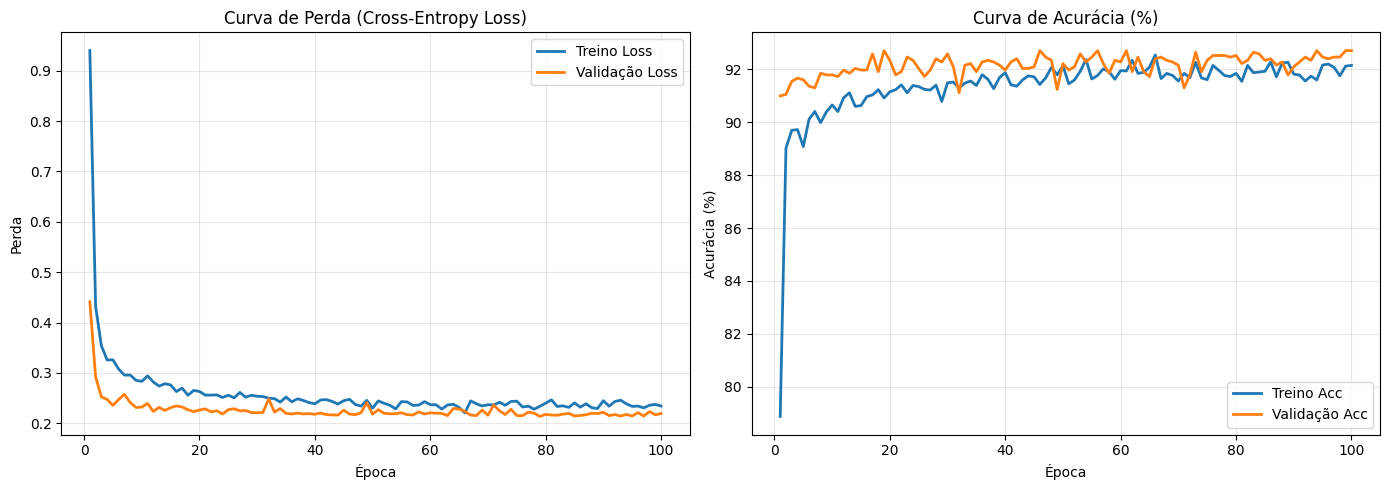

In [54]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Treino Loss", lw=2)
plt.plot(epochs_range, history["val_loss"], label="Validação Loss", lw=2)
plt.title("Curva de Perda (Cross-Entropy Loss)")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in history["train_acc"]], label="Treino Acc", lw=2)
plt.plot(epochs_range, [acc * 100 for acc in history["val_acc"]], label="Validação Acc", lw=2)
plt.title("Curva de Acurácia (%)")
plt.xlabel("Época")
plt.ylabel("Acurácia (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Avaliação de Desempenho e Diagnóstico de Erros (Modelo Inicial - 70% Treino)

Avaliamos o modelo restaurado em sua melhor época tanto no conjunto de **Validação (15%)** quanto no conjunto de **Teste Interno (15%)**.

### 📊 Análise das Métricas por Classe:
* **100% em Precision, Recall e F1-Score**. Por ser uma semente significativamente maior em área e perímetro, suass descrições formam um agrupamento perfeitamente separável.
Apresentam os maiores níveis de confusão recíproca na Matriz de Confusão, reflexo direto de suas semelhanças geométricas de compacidade e excentricidade.
* **Desempenho Geral**: O modelo alcança **93% de Acurácia Global** e **0.94 de Macro F1**, confirmando alto poder discriminatório mesmo diante do forte desbalanceamento entre as classes.


              precision    recall  f1-score   support

    BARBUNYA       0.93      0.94      0.93       159
      BOMBAY       1.00      1.00      1.00        63
        CALI       0.93      0.95      0.94       196
    DERMASON       0.92      0.91      0.92       427
       HOROZ       0.97      0.94      0.95       228
       SEKER       0.96      0.97      0.97       242
        SIRA       0.86      0.87      0.87       318

    accuracy                           0.93      1633
   macro avg       0.94      0.94      0.94      1633
weighted avg       0.93      0.93      0.93      1633



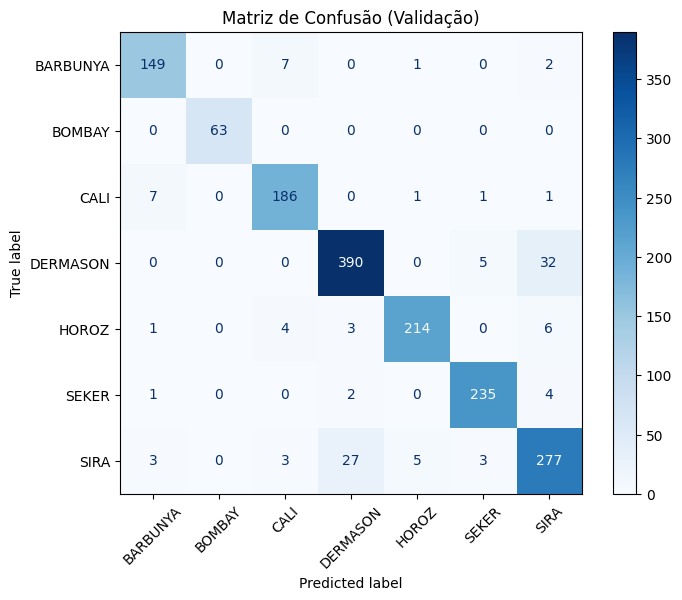

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.94      0.94       160
      BOMBAY       1.00      1.00      1.00        62
        CALI       0.94      0.96      0.95       196
    DERMASON       0.92      0.92      0.92       428
       HOROZ       0.96      0.96      0.96       228
       SEKER       0.95      0.93      0.94       242
        SIRA       0.88      0.89      0.88       318

    accuracy                           0.93      1634
   macro avg       0.94      0.94      0.94      1634
weighted avg       0.93      0.93      0.93      1634



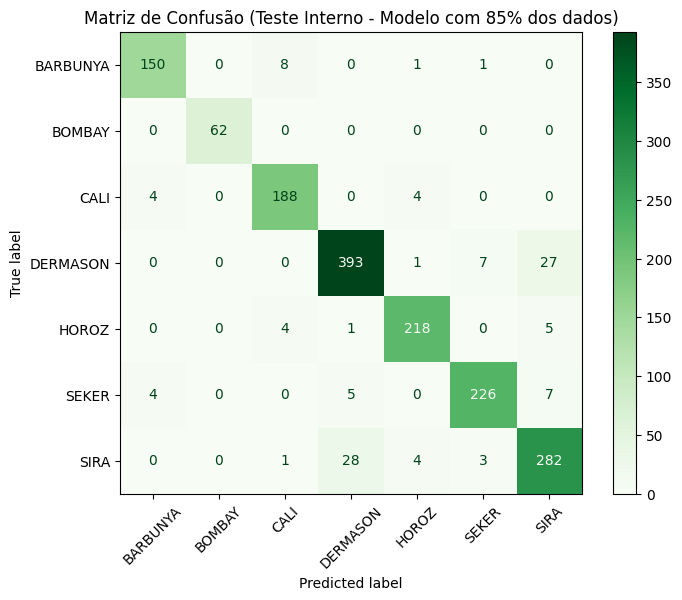

In [55]:
# Avaliação no conjunto de Validação que representa 15% dos dados do todo
model.eval()
val_preds = []
val_targets = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        val_preds.extend(preds.cpu().numpy())
        val_targets.extend(labels.numpy())

print(classification_report(val_targets, val_preds, target_names=encoder.classes_))

cm_val = confusion_matrix(val_targets, val_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=encoder.classes_)
disp_val.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusão (Validação)")
plt.show()

# Avaliação no conjunto de Teste Interno (15%) - Modelo Treinado em 70%
test_preds = []
test_targets = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.numpy())

print(classification_report(test_targets, test_preds, target_names=encoder.classes_))

cm_test = confusion_matrix(test_targets, test_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=encoder.classes_)
disp_test.plot(cmap="Greens", ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusão (Teste Interno - Modelo com 85% dos dados)")
plt.show()


## 9. Retreinamento com Treino + Validação Concatenados (85%)

Após a validação bem-sucedida dos hiperparâmetros e a identificação do ponto de parada ideal (`best_epoch = 19`), usei a estratégia de maximização amostral:

1. **Fusão Amostral**: Combinamos os dados de Treino (70%) e Validação (15%) em uma partição consolidada de **85% do total de dados rotulados** (9.254 amostras).
2. **Reajuste do Escalonador**: Ajustamos um novo `StandardScaler` sobre a totalidade dos 85% dos dados, gerando estimativas estatísticas ainda mais precisas para a transformação do teste interno e do teste da competição.
3. **Treinamento pelo Número Ótimo de Épocas**: Treinamos um novo modelo `BeansClassifier` estritamente durante o número de épocas identificado como ótimo (`best_epoch = 19`). Esse procedimento transfere à rede o benefício de mais dados de treino sem expô-la ao risco de sobreajuste.


In [56]:
# Concatenação de Treino e Validação usando agora 85% dos dados.
X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True) # concatena os dados
y_train_val = np.concatenate([y_train, y_val], axis=0) 


scaler = StandardScaler()

X_train_val_scaled = scaler.fit_transform(X_train_val) # retreinando os dados
X_test_scaled = scaler.transform(X_test)

train_val_dataset = TensorDataset(
    torch.tensor(X_train_val_scaled, dtype=torch.float32),
    torch.tensor(y_train_val, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_val_loader = DataLoader(train_val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Amostras Treino + Validação (85%): {len(train_val_dataset)} ({len(train_val_loader)} batches)")
print(f"Amostras Teste Interno (15%): {len(test_dataset)} ({len(test_loader)} batches)")


Amostras Treino + Validação (85%): 9254 (145 batches)
Amostras Teste Interno (15%): 1634 (26 batches)


### 9.1 Inicialização e Treinamento do Modelo Expandido

É feita uma nova rede com a mesma configuração de camadas e hiperparâmetros, executando a otimização ao longo das 19 épocas ótimas.


In [57]:
# Inicialização do modelo agora com um volume total de 85% dos daods totais
model = BeansClassifier(input_dim=16, num_classes=7, dropout_rate=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Treinamento pela quantidade ótima de épocas q foi criado la na validação.
for epoch in range(1, best_epoch + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    if epoch % 5 == 0 or epoch == 1 or epoch == best_epoch:
        print(f"Época [{epoch:02d}/{best_epoch}] | Loss: {epoch_loss:.4f} | Acc: {epoch_acc*100:.2f}%")


Época [01/19] | Loss: 0.8790 | Acc: 79.95%
Época [05/19] | Loss: 0.3155 | Acc: 89.63%
Época [10/19] | Loss: 0.2806 | Acc: 90.46%
Época [15/19] | Loss: 0.2787 | Acc: 90.48%
Época [19/19] | Loss: 0.2634 | Acc: 90.89%


### 9.2 Avaliação Cega no Teste Interno (15%) com Modelo de 85%

Avaliamos o modelo retreinado na partição de Teste Interno mantida intacta:
* O modelo sustenta **93% de acurácia global** e **Macro F1 de 0.94**, comprovando solidez e capacidade de generalização idêntica ou superior ao modelo original.


              precision    recall  f1-score   support

    BARBUNYA       0.94      0.93      0.94       160
      BOMBAY       1.00      1.00      1.00        62
        CALI       0.95      0.95      0.95       196
    DERMASON       0.90      0.95      0.92       428
       HOROZ       0.97      0.96      0.97       228
       SEKER       0.97      0.92      0.94       242
        SIRA       0.89      0.87      0.88       318

    accuracy                           0.93      1634
   macro avg       0.95      0.94      0.94      1634
weighted avg       0.93      0.93      0.93      1634



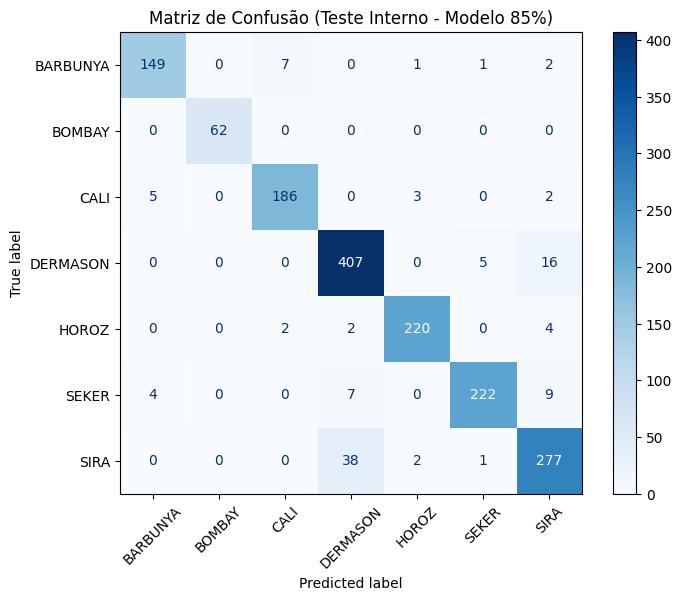

In [58]:
# Avaliação do modelo q agora tem 85% dos dados no conjunto de Teste Interno
model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.numpy())


print(classification_report(test_targets, test_preds, target_names=encoder.classes_))

matriz_C = confusion_matrix(test_targets, test_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_C, display_labels=encoder.classes_)
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusão (Teste Interno - Modelo 85%)")
plt.show()


## 10. Inferência no Conjunto de Teste da Competição e Geração da Submissão



In [59]:
# Inferência nos dados da competição usando o modelo retreinado com mais dados (85%)
X_test_competicao_scaled = scaler.transform(df_test)
X_test_competicao_tensor = torch.tensor(X_test_competicao_scaled, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_competicao_tensor)
    _, test_preds = torch.max(test_outputs, 1)

test_preds_labels = encoder.inverse_transform(test_preds.cpu().numpy())

df_submission = pd.DataFrame({"Class": test_preds_labels})
submission_file = "submission.csv"
df_submission.to_csv(submission_file, index=False)

print(f"Total de linhas: {len(df_submission)} (esperamos que seja 2723)")
print(df_submission.head())
print("\nDistribuição das predições no teste da competição:")
print(df_submission["Class"].value_counts())


Total de linhas: 2723 (esperamos que seja 2723)
      Class
0     SEKER
1     SEKER
2     HOROZ
3  BARBUNYA
4      CALI

Distribuição das predições no teste da competição:
Class
DERMASON    712
SIRA        520
SEKER       411
HOROZ       395
CALI        324
BARBUNYA    255
BOMBAY      106
Name: count, dtype: int64
